Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.


TypeError: clip() got an unexpected keyword argument 'a_max'

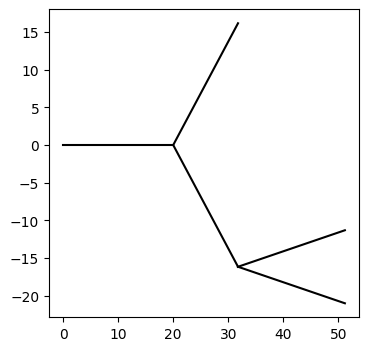

In [1]:
import jaxley as jx
from jaxley.channels import Na, K, Leak
import matplotlib.pyplot as plt


# Build the cell.
comp = jx.Compartment()
branch = jx.Branch(comp, ncomp=2)
cell = jx.Cell(branch, parents=[-1, 0, 0, 1, 1])

# Insert channels.
cell.insert(Leak())
cell.branch(0).insert(Na())
cell.branch(0).insert(K())

# Change parameters.
cell.set("axial_resistivity", 200.0)

# Visualize the morphology.
cell.compute_xyz()
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
cell.vis(ax=ax)

# Stimulate.
current = jx.step_current(i_delay=1.0, i_dur=1.0, i_amp=0.1, delta_t=0.025, t_max=10.0)
cell.branch(0).loc(0.0).stimulate(current)

# Record.
cell.branch(0).loc(0.0).record("v")

# Simulate and plot.
v = jx.integrate(cell, delta_t=0.025)
plt.plot(v.T)
